Import Library Dan Import Dataset

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

print(df.head())
print("Shape Awal:", df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Shape Awal: (541909, 8)


Melakukan Cleaning pada dataset

In [ ]:
# Hapus CustomerID kosong
df = df.dropna(subset=['CustomerID'])

# Hapus Quantity <= 0
df = df[df['Quantity'] > 0]

# Hapus UnitPrice <= 0
df = df[df['UnitPrice'] > 0]

# Hapus transaksi retur
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Shape Setelah Cleaning:", df.shape)  

Shape Setelah Cleaning: (397884, 8)


Membuat TotalPrice 

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


Membuat Snapshot

In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


Membuat Recency

In [ ]:
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (
    snapshot_date - recency['InvoiceDate']
).dt.days

recency = recency[['CustomerID', 'Recency']]

recency.head()

,CustomerID,Recency
0,12346.0,326
1,12347.0,2
2,12348.0,75
3,12349.0,19
4,12350.0,310


Membuat Frequency

In [ ]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

frequency.columns = [
    'CustomerID',
    'Frequency'
]

frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


Membuat Monetary

In [ ]:
monetary = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()

monetary.columns = [
    'CustomerID',
    'Monetary'
]

monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


Menggabungkan RFM

In [ ]:
rfm = recency.merge(
    frequency,
    on='CustomerID'
)

rfm = rfm.merge(
    monetary,
    on='CustomerID'
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


Membuat Statistik RFM

In [ ]:
print(rfm.describe())

         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


Normalisasi RFM

In [ ]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency','Frequency','Monetary']]
)

print("Normalisasi selesai")

Normalisasi selesai


Elbow Method

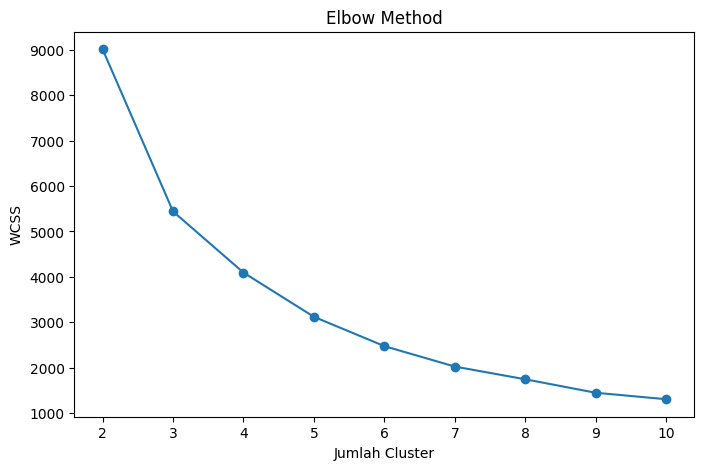

In [ ]:
wcss = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

K-Means Clustering

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


Silhouette Score

In [ ]:
score = silhouette_score(
    rfm_scaled,
    rfm['Cluster'],
    sample_size=1000,
    random_state=42
)

print("Silhouette Score:", round(score,4))

Silhouette Score: 0.608


Mengitung Jumlah Anggota Cluster

In [ ]:
cluster_count = (
    rfm['Cluster']
    .value_counts()
    .sort_index()
)

print(cluster_count)

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


Mengklasifikasi Karakteristik Tiap Cluster

In [ ]:
cluster_detail = rfm.groupby(
    'Cluster'
).agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean',
    'CustomerID':'count'
}).round(2)

cluster_detail.columns = [
    'Avg_Recency',
    'Avg_Frequency',
    'Avg_Monetary',
    'Jumlah_Customer'
]

cluster_detail

,Avg_Recency,Avg_Frequency,Avg_Monetary,Jumlah_Customer
Cluster,,,,
0,43.70,3.68,1359.05,3054
1,248.08,1.55,480.62,1067
2,7.38,82.54,127338.31,13
3,15.50,22.33,12709.09,204


Visualisasi Cluster

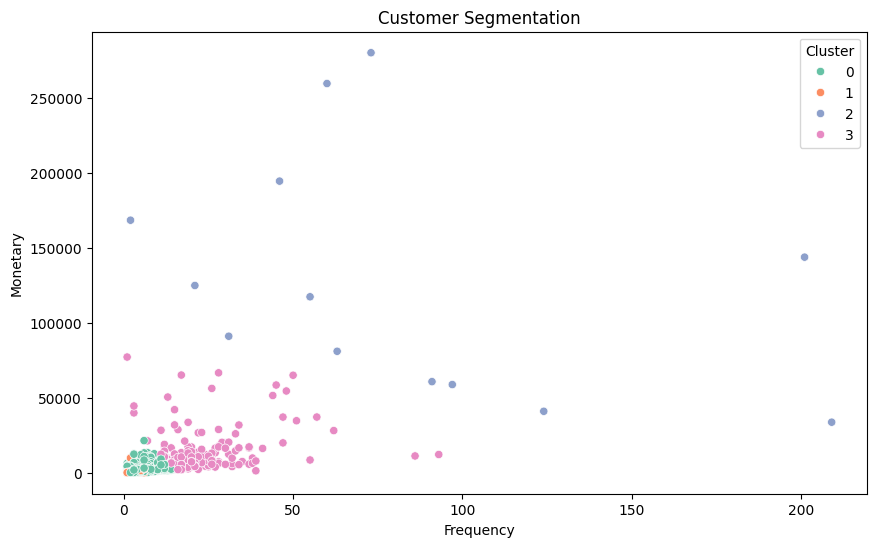

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segmentation")

plt.show()

Export Hasil

In [ ]:
rfm.to_excel(
    "hasil_segmentasi_rfm.xlsx",
    index=False
)

cluster_detail.to_excel(
    "ringkasan_cluster.xlsx"
)

print("Berhasil disimpan")

Berhasil disimpan
